# 27회차 기출문제


## 문제 1

**Description**

신용카드 사기 탐지 모형 개발

-   amount : 거래금액

-   time : 거래된 기간

-   V1 \~ V17 : 비식별된 칼럼

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
dat = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/27/problem1.csv')
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   v1      1234 non-null   float64
 1   v2      1234 non-null   float64
 2   v3      1234 non-null   float64
 3   v4      1234 non-null   float64
 4   v5      1234 non-null   float64
 5   v6      1234 non-null   float64
 6   v7      1234 non-null   float64
 7   v8      1234 non-null   float64
 8   v9      1234 non-null   float64
 9   v10     1234 non-null   float64
 10  v11     1234 non-null   float64
 11  v12     1234 non-null   float64
 12  v13     1234 non-null   float64
 13  v14     1234 non-null   float64
 14  v15     1234 non-null   float64
 15  v16     1234 non-null   float64
 16  v17     1234 non-null   float64
 17  time    1234 non-null   int64  
 18  amount  1234 non-null   float64
 19  class   1234 non-null   int64  
dtypes: float64(18), int64(2)
memory usage: 192.9 KB


### 1. EDA를 실시하시오.

In [4]:
dat.isna().sum()

v1        0
v2        0
v3        0
v4        0
v5        0
v6        0
v7        0
v8        0
v9        0
v10       0
v11       0
v12       0
v13       0
v14       0
v15       0
v16       0
v17       0
time      0
amount    0
class     0
dtype: int64

In [5]:
dat.head(3)

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,time,amount,class
0,1.920111,0.054060,-1.652592,1.436783,0.373198,-1.128981,0.720770,-0.435789,0.191145,0.231149,-0.966937,0.340753,-0.226582,0.541256,-0.514528,-0.733271,-0.126476,123532,64.80,0
1,0.326698,0.163725,-2.816580,-2.698640,3.106658,2.751206,0.517053,0.523334,-1.486486,-0.114324,0.106818,-1.100110,-0.409329,-0.971973,-0.601476,0.544973,1.248596,137386,40.35,0
2,-0.347783,0.648108,0.545413,-2.528817,1.166868,0.091964,1.030637,-0.126029,0.514945,-1.051795,0.529743,1.070820,0.897411,0.027990,0.426925,-0.326463,-1.093126,3374,1.00,0


In [6]:
dat['class'].value_counts()

0    1193
1      41
Name: class, dtype: int64

--통계량--


,count,mean,std,min,25%,50%,75%,max
v1,1234.0,-0.110618,2.273262,-28.524268,-0.998934,0.027135,1.311592,2.327704
v2,1234.0,0.104890,1.732450,-13.207144,-0.599064,0.077232,0.816358,15.876923
v3,1234.0,-0.217778,2.207837,-29.468732,-1.017649,0.109973,0.947341,3.453800
v4,1234.0,0.096729,1.581508,-4.651087,-0.781095,-0.032909,0.753119,12.114672
v5,1234.0,-0.160525,1.667041,-20.786000,-0.777116,-0.132789,0.606325,7.956615
v6,1234.0,-0.040954,1.226511,-5.140999,-0.759455,-0.243985,0.379618,4.849632
v7,1234.0,-0.163928,1.828478,-28.011293,-0.632784,-0.005860,0.524712,8.848478
v8,1234.0,0.080133,1.360335,-15.487784,-0.196499,0.055000,0.367575,18.748872
v9,1234.0,-0.041368,1.244023,-8.960922,-0.625591,-0.030621,0.608770,7.938980
v10,1234.0,-0.201199,1.714592,-18.913243,-0.623216,-0.128174,0.376954,11.519106


<양의 왜도: 오른쪽 긴꼬리>
v4        1.656632
v6        1.060493
v11       1.613446
amount    5.190480
dtype: float64
<음의 왜도: 왼쪽 긴꼬리>
v1    -3.659418
v3    -5.179244
v5    -3.620015
v7    -5.935638
v10   -3.619901
v12   -5.013651
v14   -4.196382
v16   -4.421602
v17   -6.774575
dtype: float64


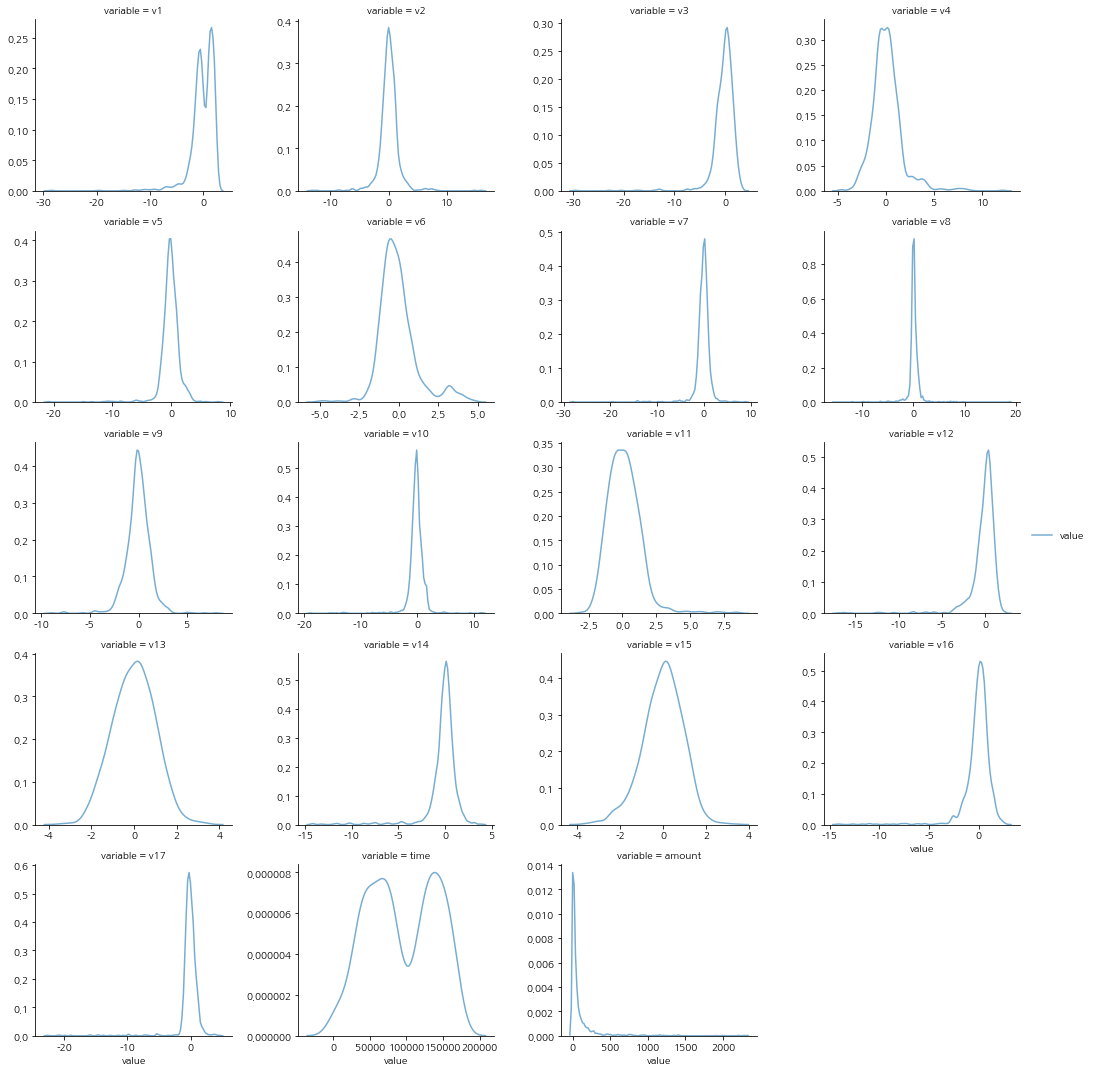

In [7]:
n_cols = dat.columns[:-1]

print(f"--통계량--")
display(dat[n_cols].describe().T)

print("<양의 왜도: 오른쪽 긴꼬리>")
print(dat[n_cols].skew()[dat[n_cols].skew() > 1])

print("<음의 왜도: 왼쪽 긴꼬리>")
print(dat[n_cols].skew()[dat[n_cols].skew() < -1])

mt = dat[n_cols].melt()
g = sns.FacetGrid(mt, col='variable',
                  col_wrap=4, sharex=False, sharey=False, height=3, aspect=1.2)
g.map(sns.kdeplot, 'value', alpha=0.6)
g.add_legend()
plt.show()

전체 데이터 기준 통계량 및 연속형 분포를 시각화하였다.  
v2, v13 등 일부 변수를 제외하고는 대체로 양, 음의 왜도를 가진다.   
왜도가 0에 가까운 값을 가지면 정규분포를 따르는데, 임계치를 1로 두었을 때   

<양의 왜도: 오른쪽 긴꼬리(yeo johnson 등 고려: 0이하의 값이므로)>
- v4        1.656632
- v6        1.060493
- v11       1.613446
- amount    5.190480


<음의 왜도: 왼쪽 긴꼬리(지수화 등 고려)>
- v1    -3.659418
- v3    -5.179244
- v5    -3.620015
- v7    -5.935638
- v10   -3.619901
- v12   -5.013651
- v14   -4.196382
- v16   -4.421602
- v17   -6.774575
의 결과를 확인할 수 있다. 

또한 시간은 쌍봉분포를 보인다(5000, 15000 구간)

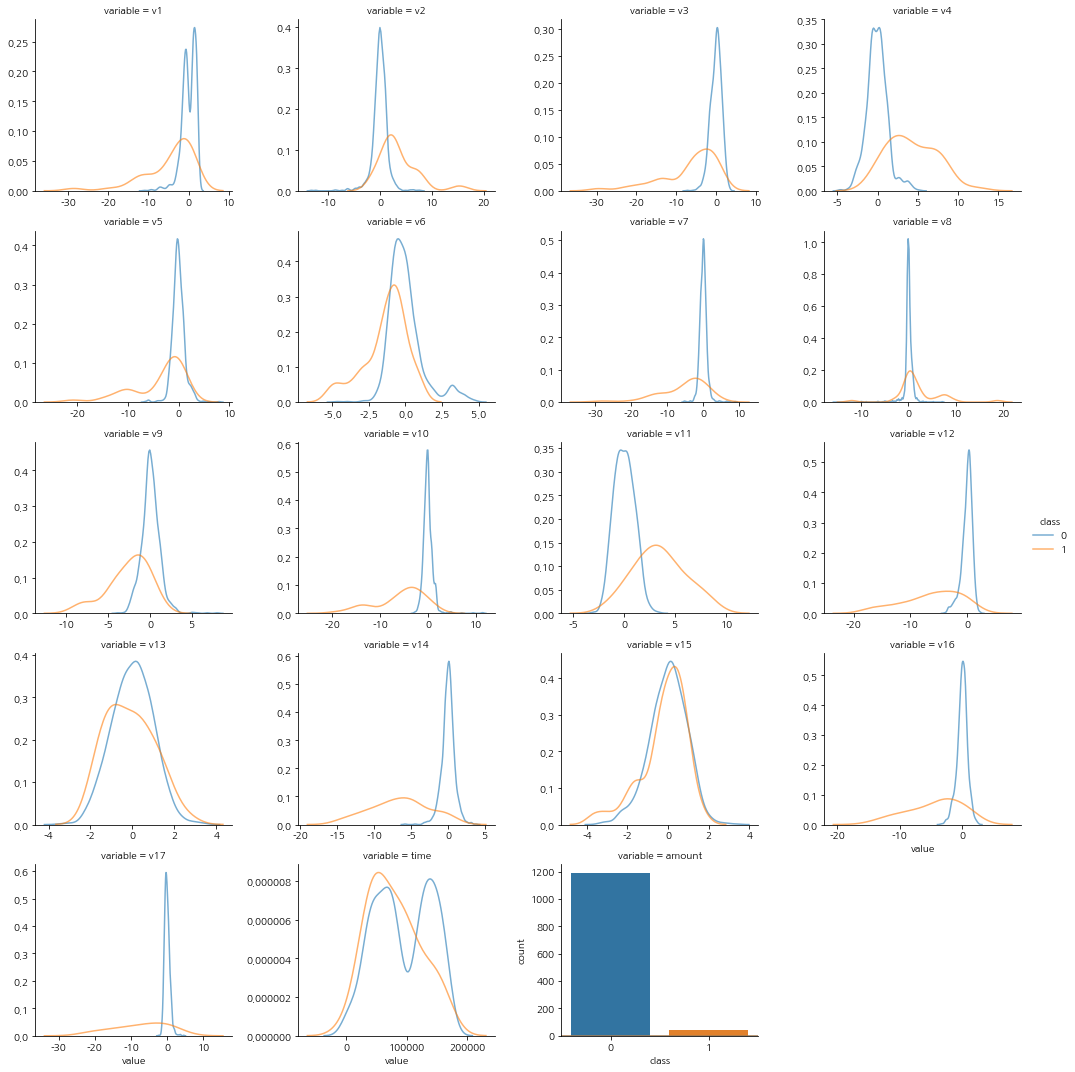

In [8]:
mt = dat.melt(id_vars='class')
g = sns.FacetGrid(mt, col='variable', hue='class', 
                  col_wrap=4, sharex=False, sharey=False, height=3, aspect=1.2)
g.map(sns.kdeplot, 'value', alpha=0.6)
g.add_legend()
sns.countplot(dat['class'])
plt.show()

클래스는 이진변수이며, 0의 값이 확연히 많은 불균형 분포를 보인다.  
그리고 클래스 기준으로 v15를 제외한 대다수의 변수에서 분포가 확연히 다른 특징을 보임을 알 수 있다.  
(예: time에서 0은 쌍봉분포를 보이지만, 1은 그렇지 않음)

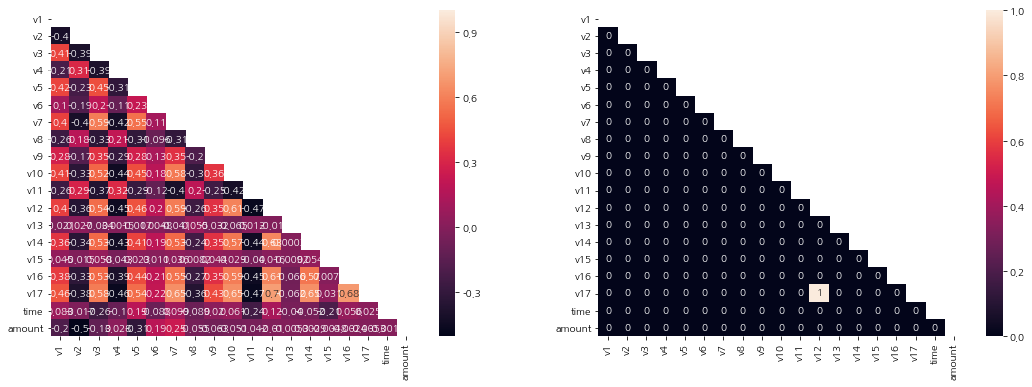

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
corr = dat[n_cols].corr()
corr2 = dat[n_cols].corr()>0.7
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True, ax=ax[0])
mask2 = np.triu(np.ones_like(corr2, dtype='bool'))
sns.heatmap(corr2, mask=mask2, annot=True, ax=ax[1])
plt.show()

피어슨 상관관계 결과로 선형 상관관계를 확인할 수 있다. 절대값 0.7를 임계치로 임의로 설정했을 때 v12-17을 제외하고는    
다중공선성이 있는 feature 쌍이 관찰되지 않는다.
보다 확실하게 다중공선성을 확인하기 위해 vif를 확인한다. vif가 10 이상이면 다중공선성으로 진단한다.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(dat[n_cols].values, i) for i in range(len(n_cols))]
display(vif)

,name,vif
0,v1,2.238064
1,v2,3.732927
2,v3,2.571506
3,v4,1.580276
4,v5,3.671952
5,v6,1.522030
6,v7,5.141979
7,v8,1.311795
8,v9,1.294389
9,v10,2.282507


예상과는 달리 10이상의 값이 없어, 다중공선성이 있다고 볼 수 없다.   
보통 10 이상인 경우 다중공선성으로 보고, 보수적으로 5~10 사이의 값이 있다면 문제에 따라 판단하기도 하지만  
대체로 5미만의 값이며, 5-10사이의 값도(v7, amount) 5에 가까우므로 다중공선성이 크지 않다고 판단한다. 

### 2. 차원축소가 필요한지 검토하시오. 2개 이상의 후보 알고리즘을 비교하고, 1개를 추천하시오.

해당 데이터에서는 차원축소를 고려하지 않는다.  
각 클래스에 대한 feature의 분포 특징이 뚜렷하며, 심각한 다중공선성이 없고, 차원도 크지 않다.  
차원축소는 다중공선성을 완화하며, 저차원으로 데이터를 변환하여 시간/비용을 절감시켜 주는 특징을 가지고 있다.  

만약 다중공선성, 고차원으로 차원축소가 필요하다면 다음 두 가지 방법을 제안하며, PCA를 추천한다. 
1. PCA: 데이터의 분산이 큰 방향으로 축을 찾아 데이터를 저차원으로 투영하는 차원축소 기법, 원본특성 간의 상관관계를 이용해 서로 직교하는 새 주성분을 만들고, 이 중 분산이 큰 순서대로 데이터를 표현해 정보손실 최소화
- 장점: 차원축소, 노이즈 제거, 시각화, 상관성 해소
- 단점: 해석 어려움, 선형성 가정 필요, 스케일 민감, 정보 손실
2. LDA: 지도학습 기반 차원축소, 클래스 간 분산을 최대화하고 클래스 내 분산을 최소화하는 축에 데이터를 투영하여 분류성능을 높이는 방법
- 장점: 공분산 구조 반영, 견고성, 다중클래스 분류, 차원축소와 분류 동시수행
- 단점: 샘플크기 제약(가장 작은 그룹샘플수가 특성개수보다 많아야 함), 정규분포 가정, 공분산 구조 제약, 선형성 한계


### 3. 추천한 알고리즘을 구현하고, 정당성을 제시하시오.



,고윳값,분산설명력,누적분산설명력
0,90.409312,0.348624,0.348624
1,44.388406,0.084037,0.432661
2,41.213960,0.072447,0.505108
3,35.541914,0.053878,0.558986
4,34.990494,0.052219,0.611206
5,33.786478,0.048687,0.659893
6,33.001540,0.046451,0.706345
7,31.757290,0.043015,0.749359
8,30.622970,0.039997,0.789356
9,29.215716,0.036405,0.825762


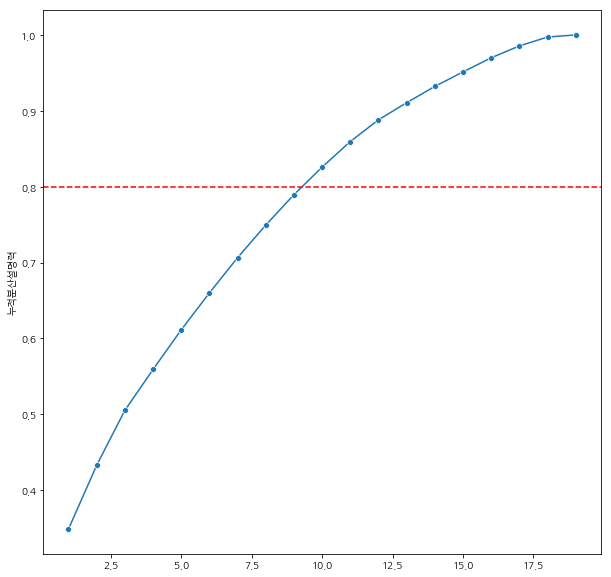

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = dat.drop('class', axis=1)
Y = dat['class']

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42, stratify=Y)

sc = StandardScaler()
pca = PCA()

train_X_r = pd.DataFrame(sc.fit_transform(X), columns=train_X.columns)
pca.fit_transform(train_X_r)

rs = pd.DataFrame({'고윳값': pca.singular_values_, 
                  '분산설명력': pca.explained_variance_ratio_, 
                  '누적분산설명력': np.cumsum(pca.explained_variance_ratio_)})

display(rs)

plt.figure(figsize=(10, 10))
sns.lineplot(data=rs, x=rs.index+1, y='누적분산설명력', marker='o')
plt.axhline(y=0.8, ls='--', color='r')
plt.show()

분산설명력 scree plot상 두번째 주성분에서 분산설명력이 급감하며,(즉, 첫번째 주성분이 전체 데이터의 약 34% 이상을 설명), 주성분 10개 선택 시 약 82% 분산설명력을 가짐. 하지만 다중공선성이 강하지 않으며, 차원축소 효과가 획기적이지 않으므로(차원의 수가 크지 않은데다가 18-> 10으로 차원축소) 적용하지 않는다.

### 4. Over sampling / under sampling의 장단점을 기술하시오. 적절한 샘플링을 제안하고 구현하시오.

- 오버샘플링: minority class의 데이터를 majoiry class에 맞추어 증강시키는 방법, 
    - 장점: 정보 결손이 없으며, 불균형을 해소하여 모델 성능 향상효과
    - 단점: 기법(randomoversampling)에 따라 과적합이 될 수 있음
- 언더샘플링: majority class를 minority class에 맞추어 감소시키는 방법
    - 장점: 전체 데이터수가 줄어들어 연산량이 적어짐, 적용이 간편함
    - 단점: 정보의 결손이 있음
    
여기서는 오버샘플링 기법인 SMOTE를 적용한다. 

In [15]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from collections import Counter

# SMOTE 적용 파이프라인
after = make_pipeline(
    StandardScaler(), 
    SMOTE(random_state=42)
)

r_X, r_Y = after.fit_resample(train_X, train_Y)

print(f"smote 적용 전 각 클래스 데이터 수:{Counter(train_Y)}")
print(f"smote 적용 후 각 클래스 데이터 수:{Counter(r_Y)}")

smote 적용 전 각 클래스 데이터 수:Counter({0: 894, 1: 31})
smote 적용 후 각 클래스 데이터 수:Counter({0: 894, 1: 894})


smote를 통해 각 클래스 데이터 수가 class 0에 맞춰 {0: 894, 1: 894}로 증강된 것을 확인할 수 있다.

### 5. 이전 결과를 활용하여 사기 분류 모델 2개를 구현하고 성능을 비교하시오.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report


rf = RandomForestClassifier(random_state=42)
lgbm = LGBMClassifier(random_state=42)

model_list = [('랜덤포레스트 분류모델', rf), ('LGMB 모델', lgbm)]
dt_list = [('train', r_X, r_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns = ['model', 'data', 'f1', 'recall', 'precision'])

for m_name, model in model_list:
    model.fit(r_X, r_Y)
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        f1 = f1_score(y, pred, average='macro')
        recall = recall_score(y, pred, average='macro')
        precision = precision_score(y, pred, average='macro')
        print(classification_report(y, pred))
        rs.loc[len(rs)] = [m_name, d_name, f1, recall, precision]
display(rs)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       894
           1       1.00      1.00      1.00       894

    accuracy                           1.00      1788
   macro avg       1.00      1.00      1.00      1788
weighted avg       1.00      1.00      1.00      1788

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       299
           1       1.00      0.70      0.82        10

    accuracy                           0.99       309
   macro avg       1.00      0.85      0.91       309
weighted avg       0.99      0.99      0.99       309

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       894
           1       1.00      1.00      1.00       894

    accuracy                           1.00      1788
   macro avg       1.00      1.00      1.00      1788
weighted avg       1.00      1.00      1.00      1788

              preci

,model,data,f1,recall,precision
0,랜덤포레스트 분류모델,train,1.000000,1.000000,1.000000
1,랜덤포레스트 분류모델,test,0.909269,0.850000,0.995033
2,LGMB 모델,train,1.000000,1.000000,1.000000
3,LGMB 모델,test,0.827471,0.843311,0.813148


배깅과 부스팅 방식의 트리기반 앙상블 모델을 통해 사기분류 모델을 적합하였다.  
전반적으로 랜덤 포레스트 모델의 성능이 뛰어나므로 해당 모델을 채택한다 .

### 6. 이상탐지(anomaly detection) 방법을 사용하여 신용카드 사기 데이터를 식별하시오.

In [34]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

isol = IsolationForest(random_state=42)

isol.fit(r_X, r_Y)

preds = isol.fit_predict(test_X)
test_Y_r = np.where(test_Y == 0, 1, -1)

print(classification_report(test_Y_r, preds))
cm = pd.DataFrame(confusion_matrix(test_Y_r, preds), index=['실제 사기', '실제 정상'], columns=['예측 사기', '예측정상'])
display(cm)

              precision    recall  f1-score   support

          -1       0.47      0.70      0.56        10
           1       0.99      0.97      0.98       299

    accuracy                           0.96       309
   macro avg       0.73      0.84      0.77       309
weighted avg       0.97      0.96      0.97       309



,예측 사기,예측정상
실제 사기,7,3
실제 정상,8,291


대표적인 사기탐지 모델인 IsolationForest을 적용하여 사기데이터를 식별한 결과이다.  
별도의 파라미터 튜닝을 거치지 않고도 recall 0.7로 실제 사기데이터의 70%를 잘 예측해 냄을 알 수 있다. 

## 2 문제 2(변형 문제)

In [17]:
dat = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/27/problem2.csv')
dat.head()

,...1,id,gender,math,daysabs,prog
0,1,1001,male,63,4,Academic
1,2,1002,male,27,4,Academic
2,3,1003,female,20,2,Academic
3,4,1004,female,16,3,Academic
4,5,1005,female,2,3,Academic


In [18]:
dat = dat.iloc[:, 1:]
dat.set_index('id', drop=True, inplace=True)

### 1.데이터가 과대산포 되어있는지 확인하시오.


In [19]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 314 entries, 1001 to 2157
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   gender   314 non-null    object
 1   math     314 non-null    int64 
 2   daysabs  314 non-null    int64 
 3   prog     314 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.3+ KB


과대산포는 주로 사건발생횟수를 모델링할 때 발생하는 현상으로, 관측된 데이터의 분산이 이론적으로 가정한 분포의 분산보다 크게  
나타나는 현상이다. 

과대산포 여부는 평균과 분산의 비로 알 수 있는데 분산/평균의 값이 1 이상인 경우 과대산포가 있다고 할 수 있다. 

In [20]:
c_cols = dat.select_dtypes('number').columns

for col in c_cols:
    ratio = dat[col].var(ddof=1)/dat[col].mean()
    print(f"{col} 변수 분산/평균 비: {ratio}")

math 변수 분산/평균 비: 13.326786721609638
daysabs 변수 분산/평균 비: 8.314916881652458


두 연속형 변수의 분산/평균비가 1 이상이므로 과대산포가 있다.

### 2. 포아송 회귀 모델과 음이항 회귀 모델 중 적합한 모델을 선택하고, 이유를 기술하시오.


포아송 회귀모델은 분산/평균이 동일한(과대산포가 없는) 경우를 가정하는 모델이므로 과대산포가 있을 때도 사용할 수 있는 음이항 회귀모델을 사용한다.  

- 포아송 회귀를 사용하면 분산을 평균(u)로 고정해 표준오차를 계산하므로 실제 분산이 더 크다면 표준오차가 낮아져  
회귀계수의 유의도가 과대평가되고, 신뢰구간이 지나치게 좁아짐  
또한 잔차분석 시 잔차가 클러스터링 되는 등 패턴이 남아있게 되어 모델의 예측력과 해석력을 저하시킴

### 3. 모델 적합도 검정을 수행하시오.

유의수준 5% 하에서 다음의 가정을 가지고 분석을 수행한다.    
모델 적합 후 우도비 검정을 통해 다음의 가설 기각 여부를 판단한다.  

- 귀무가설: 모든 회귀계수는 0이다. 
- 대립가설: 적어도 하나의 회귀계수는 0이 아니다. 

In [22]:
from statsmodels.api import GLM, families
from scipy.stats import chi2

formula = 'daysabs~C(gender)+math+C(prog)'
model = GLM.from_formula(formula, data=dat, family=families.NegativeBinomial()).fit()

In [23]:
# 우도비 검정
s = model.null_deviance - model.deviance
rv = chi2(loc=0, scale=1, df=model.df_model)
p = 1 - rv.cdf(s)

print(f"우도비 검정통계량 : {s}")
print(f"우도비 검정통계량의 p-value: {p}")
print(f"유의수준 5% 하 귀무가설을", "기각" if p < 0.05 else "채택")

우도비 검정통계량 : 70.0332384217457
우도비 검정통계량의 p-value: 2.2315482794965646e-14
유의수준 5% 하 귀무가설을 기각


음이항 회귀모델 적합 후 유의수준 5% 하에서 우도비 검정 결과 p-value  
2.2315482794965646e-14로 귀무가설을 기각하므로 모델은 통계적으로 적합하다.   
따라서 적어도 하나의 회귀계수는 0이 아니다.

### 4. 각 회귀계수의 통계적 유의성에 관해 기술하시오.


- 귀무가설 : 해당 회귀계수가 0이다.
- 대립가설 : 해당 회귀계수가 0이 아니다.

In [25]:
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      309
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -864.25
Date:                Sat, 20 Sep 2025   Deviance:                       348.13
Time:                        21:45:13   Pearson chi2:                     333.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1999
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.28

In [28]:
model.pvalues < 0.05

Intercept                 True
C(gender)[T.male]        False
C(prog)[T.General]        True
C(prog)[T.Vocational]     True
math                      True
dtype: bool

In [36]:
# 오즈비 해석
(np.exp(model.params[model.pvalues < 0.05][1:])-1)*100

C(prog)[T.General]       52.888487
C(prog)[T.Vocational]   -56.305190
math                     -0.620942
dtype: float64

In [38]:
dat.value_counts()

gender  math  daysabs  prog      
female  70    0        Vocational    3
        87    1        Vocational    2
male    37    0        Academic      2
female  63    6        Vocational    2
male    63    0        Vocational    2
                                    ..
        27    6        Academic      1
              4        Academic      1
        26    10       Academic      1
              1        Vocational    1
female  1     12       General       1
Length: 293, dtype: int64

유의수준 5% 하에서 gender의 p-value가 0.090으로 0.05보다 크므로 귀무가설을 기각할 수 없음. 따라서 해당 변수의 회귀계수는 통계적으로 유의하지 않다.  
나머지 변수는 0.05보다 작으므로 통계적으로 유의하다.  

통계적으로 유의한 변수에 대해서는 다음과 같이 오즈비 해석을 할 수 있다.  
- C(prog)[T.General] : Academic에 비해 daysabs될 오즈가 52.88% 높음
- C(prog)[T.Vocational]: Academic에 비해 daysabs될 오즈가 56.3% 낮음
- math: 점수가 1 오를 때마다 daysabs될 오즈가 -0.62% 낮음


## 문제 3

2년 전 회사 매출이 200,000달러, 1년 전 회사 매출이 300,000달러, 그 후 서비스 품질의 개선으로 회사 매출이 500,000달러가 되었을 때, 연평균 매출 상승률의 대푯값을 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기)

In [45]:
from scipy.stats import gmean

m = [(300000)/200000, (500000)/300000] #연간 상승률
avg_r = gmean(m)-1
print(f"연평균 매출상승률: {(avg_r*100).round(2)} %")

연평균 매출상승률: 58.11 %


## 문제 4

어느 대학교에서 무작위로 뽑은 20명의 학생들이 매주 운동하는 평균 시간이 시간으로 측정되었다.

해당 데이터의 표본 평균은 6.2, 표본편차는 1.5 이다. 이 데이터를 바탕으로, 95% 신뢰수준에서 학생들이 매주 운동하는 시간의 모평균에 대한 신뢰구간을 구하시오.

In [50]:
# 데이터의 수가 20개이며, 표본의 평균과 편차가 제공되었으므로 t분포
from scipy.stats import t
#평균, 갯수, 표본표준편차
x, n, s = 6.2, 20, 1.5
a = 0.05 #유의수준
df = n-1 #자유도

#신뢰구간 및 오차한계
se = s/np.sqrt(n)
conf = t.ppf(1-a/2, df)
me = conf*se

print(f"시간의 모평균에 대한 95% 신뢰구간: {x-me:.3f} ~ {x+me:.3f}")

시간의 모평균에 대한 95% 신뢰구간: 5.498 ~ 6.902


## 문제 5

In [51]:
dat = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/27/problem5.csv')
dat.head()

,river,up,down
0,A,60.2,48.5
1,B,49.1,40.3
2,C,58.4,55.1
3,D,61.5,56.9
4,E,59.8,48.7


강의 상류와 하류의 생물 다양성 점수에 차이가 있는지 검정하시오. (단, 같은 강에서 상류와 하류는 서로 독립적이지 않으며, 종속적인 관계에 있다.)

### 1. 귀무가설과 대립가설을 설정하시오.

두 종속적인 집단의 차이를 검정하는 문제이므로 대응표본 t검정을 실시한다.  
만약 정규성을 만족하지 않는다면, 비모수 검정인 윌콕슨 부호순위 검정을 실시한다. 

- 귀무가설: 강의 상류와 하류의 생물 다양성 점수는 차이가 없다. 
- 대립가설: 강의 상류와 하류의 생물 다양성 점수는 차이가 있다. 

### 2. 검정 통계량과 유의 확률을 구하고, 연구가설 채택여부를 판단하시오.

In [60]:
from scipy.stats import shapiro

for g in [dat['up'], dat['down']]:
    print(f"<<{g.name}>>")
    stat, p = shapiro(g)
    print(f"- shapiro wilk 검정통계량: {stat}")
    print(f"- p-value: {p}")

<<up>>
- shapiro wilk 검정통계량: 0.9730753898620605
- p-value: 0.8358495831489563
<<down>>
- shapiro wilk 검정통계량: 0.9674688577651978
- p-value: 0.7249436378479004


두 대응집단의 정규성을 모두 만족하므로 대응표본 t검정 실시

In [61]:
from scipy.stats import ttest_rel

stat, p = ttest_rel(dat['up'], dat['down'])
print(f"- 대응표본 t검정 검정통계량: {stat}")
print(f"- p-value: {p}")

- 대응표본 t검정 검정통계량: 1.7665772734750262
- p-value: 0.0942517247861658


유의수준 5% 하에서 p-value 0.0942517247861658로 0.05보다 크므로 귀무가설을 기각할 수   
없다. 따라서 강의 상류와 하류의 생물 다양성 점수는 차이가 없다.

## 문제 6

**Data description**

-   temperature : 온도

-   wind : 풍속

-   precipitation : 강수량

-   user_counts : 대여량

In [62]:
dat = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/27/problem6.csv')
dat.head()

,temperature,wind,precipitation,user_counts
0,10.400000,4.600,0.844944,6368
1,5.666667,4.625,0.040860,5902
2,4.933333,4.725,0.008696,6226
3,3.400000,2.675,0.156989,5829
4,8.900000,3.950,7.988462,7589


### 1. 분위수 회귀분석 (Quantile Regression)을 사용하여 회귀 계수를 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

- 50% 분위수로 설정함

일반적으로(중위수), 고객 수와 날씨는 어떤 연관이 있는가? 


In [76]:
from statsmodels.regression.quantile_regression import QuantReg
import statsmodels.api as sm

y = dat['user_counts']
X = dat.drop('user_counts', axis=1)

X = sm.add_constant(X)

model = QuantReg(y, X).fit(q=0.5)
print(model.summary())


                         QuantReg Regression Results                          
Dep. Variable:            user_counts   Pseudo R-squared:               0.3723
Model:                       QuantReg   Bandwidth:                       840.9
Method:                 Least Squares   Sparsity:                        5590.
Date:                Sat, 20 Sep 2025   No. Observations:                 2097
Time:                        22:53:09   Df Residuals:                     2093
                                        Df Model:                            3
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          5941.8395    198.127     29.990      0.000    5553.293    6330.386
temperature     268.8920      6.571     40.918      0.000     256.005     281.779
wind           -129.4050     46.259     -2.797      0.005    -220.124     -38.686
precipitation   -83.3843      7.891  

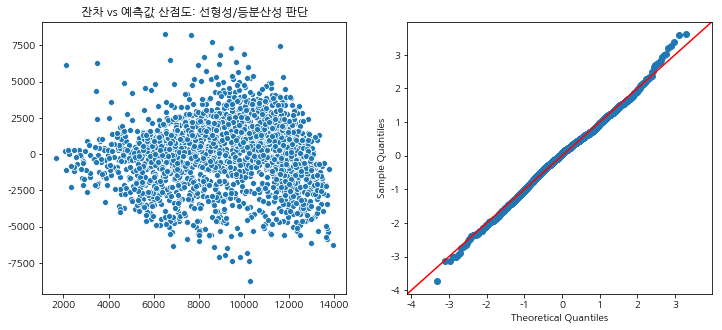

shapiro wilk p-value: 0.000
breuschpagan p-value: 0.000
durbin_watson : 1.119


In [77]:
from scipy.stats import probplot, shapiro
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# 잔차 검정: 선형성, 정규성, 등분산성, 독립성
resid = model.resid
fitted = model.fittedvalues

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=fitted, y=resid, ax=ax[0])
ax[0].set_title('잔차 vs 예측값 산점도: 선형성/등분산성 판단')
qqplot(resid, line='45', fit=True, ax=ax[1])
plt.show()
stat, p = shapiro(resid)
print(f"shapiro wilk p-value: {p:.3f}")
stat, p, _, _ = het_breuschpagan(resid, model.model.exog)
print(f"breuschpagan p-value: {p:.3f}")
dw = durbin_watson(resid)
print(f"durbin_watson : {dw:.3f}")

회귀모델의 모든 가정을 만족하지 않음(등분산 가정은 불필요하나 정규성은 만족해야 함)

In [79]:
model.params.round(2)

const            5941.84
temperature       268.89
wind             -129.41
precipitation     -83.38
dtype: float64

다음과 같이 각 변수들의 회귀계수를 소숫점 2자리 반올림하여 구하였음  
각 회귀계수들은 유의수준 5% 하에서 모두 통계적으로 유의

### 2. 이전 문제에서 구한 모델의 회귀계수를 활용하여 temperature : 10.5 , wind : 8.2 , precipitation : 3.5 일때 user_counts를 예측하시오.

In [96]:
q = pd.DataFrame({'temperature': [10.5], 
                  'wind': [8.2], 
                  'precipitation':[3.5]})
q = sm.add_constant(q, has_constant='add')

model.predict(q)

0    7412.239537
dtype: float64

해당 조건에서의 고객 수는 7412.239537로 예측된다.

## 문제 7

In [131]:
dat = pd.read_csv('https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/27_problem9.csv')
dat.head()

,line,month,total
0,1,1,1310
1,1,2,1300
2,1,3,1305
3,1,4,1200
4,1,5,1301


지하철 호선과 월별, 승객 수 간 관계가 있는지 확인하시오(Type III Anova 사용).

### 1.  귀무가설과 대립가설 설정하시오.



종속변수는 수치형 변수인 total이며, 설명변수는 명목변수인 line과 month이다.  
각 설명변수는 3개 이상의 그룹이며, 각 그룹간 대응되지 않으므로(독립적이므로)  
2-way(이원배치) 분산분석을 수행한다.  

유의수준 5% 하에서 다음과 같이 가설설정 후 검정한다.  

<주효과>
- 귀무가설: 
   - 지하철 호선에 따라 승객수 평균 차이가 없다. 
   - 월별로 승객수 평균차이가 없다. 
- 대립가설: 
    - 적어도 하나의 지하철 호선의 승객 수 평균 차이가 있다.
    - 적어도 하나의 월의 지하철 호선 승객 수 평균 차이가 있다.
    
<교호작용>
- 귀무가설: 지하철 호선과 월 간 상호작용이 없다. 
- 대립가설: 지하철 호선과 월 간 상호작용이 있다. 

교호작용 분석부터 수행 후 주효과 검정을 실시한다.  
(교호작용이 유의하다면 주효과 검정에 영향을 주므로 해석에 주의해야 함, 단순주효과 검정 수행필요)
주효과 검정 결과 유의하다면 사후검정을 통해 어떤 수준이 통계적으로 유의한지 검정한다. (보통 Tukey HSD 사용)


###  2. 검정통계량을 구하고, 대립가설 채택여부를 기술하시오.

In [132]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

dat[['line', 'month']] = dat[['line', 'month']].astype('O')

model = smf.ols(formula='total~C(line)*C(month)', data=dat).fit()

t_anova = anova_lm(model, typ=3)
print(f"이원배치 ANOVA")
display(t_anova)

이원배치 ANOVA


,sum_sq,df,F,PR(>F)
Intercept,3.466344e+06,1.0,33455.335657,4.849033e-55
C(line),1.336630e+05,2.0,645.022520,6.417946e-29
C(month),3.942483e+04,11.0,34.591616,7.896179e-16
C(line):C(month),9.696908e+04,22.0,42.540665,1.582232e-19
Residual,3.730000e+03,36.0,NaN,NaN


교호작용 효과부터 먼저 확인해보면, F 통계량의 p-value가 1.582232e-19으로  
0.05보다 확연히 작으므로 귀무가설을 기각한다. 따라서 지하철 호선과 월 간 상호작용이 있다.는 대립가설을 채택한다.  

두 독립변수의 주효과도 마찬가지로 p-value가 작아 귀무가설을 기각한다.   
하지만 교호작용이 통계적으로 유의하므로 주효과 검정결과를 그대로 해석할 수 없다.     
한 독립변수의 효과를 통제한 상태에서 사후검정을 실시하여 통계적 유의성을 확인하는 단순 주효과 검정을 수행한다.  

잔차의 정규성 검정: 0.000 정규성 불만족
잔차의 등분산 검정: 0.000 등분산성 불만족
잔차의 독립성 검정: 0.052


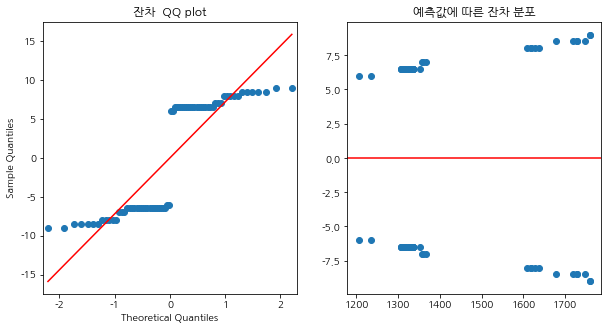

In [133]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

dat['resid'] = model.resid
gr = [group['resid'].values for name, group in dat.groupby(['line', 'month'])]

stat1, p1 = shapiro(model.resid)
stat2, p2 = levene(*gr)

print(f"잔차의 정규성 검정: {p1:.3f} 정규성", "만족" if p1 >= 0.05 else "불만족")
print(f"잔차의 등분산 검정: {p2:.3f} 등분산성", "만족" if p2 >= 0.05 else "불만족")
print(f"잔차의 독립성 검정: {durbin_watson(model.resid):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sm.qqplot(model.resid, line='s', ax=ax[0])
ax[1].scatter(model.fittedvalues, model.resid)
ax[0].set_title('잔차  QQ plot')
ax[1].set_title('예측값에 따른 잔차 분포')
ax[1].axhline(y=0, color='r')
plt.show()

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2    -10.0 0.9884  -46.0425  26.0425  False
     1      3     -5.0    1.0  -41.0425  31.0425  False
     1      4   -110.5    0.0 -146.5425 -74.4575   True
     1      5     -9.0 0.9948  -45.0425  27.0425  False
     1      6     -6.0 0.9998  -42.0425  30.0425  False
     1      7     20.0 0.5743  -16.0425  56.0425  False
     1      8    -80.5 0.0001 -116.5425 -44.4575   True
     1      9     20.0 0.5743  -16.0425  56.0425  False
     1     10     20.0 0.5743  -16.0425  56.0425  False
     1     11     20.0 0.5743  -16.0425  56.0425  False
     1     12     20.0 0.5743  -16.0425  56.0425  False
     2      3      5.0    1.0  -31.0425  41.0425  False
     2      4   -100.5    0.0 -136.5425 -64.4575   True
     2      5      1.0    1.0  -35.0425  37.0425  False
     2      6      4.0    1.0  -32.0425  40.0425

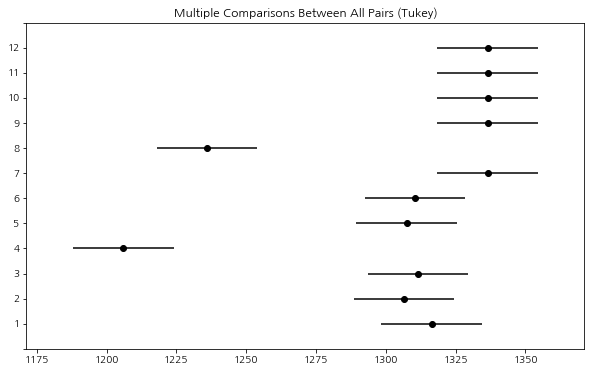

In [158]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#line을 통제한 상태에서 month 주효과 분석

for l in range(1, 2):
    dt = dat[dat['line'] == l]
    rs = pairwise_tukeyhsd(endog=dt['total'], groups=dt['month'], alpha=0.05)
    print(rs)
    rs.plot_simultaneous()
    plt.show()

각각의 독립변수의 수준을 통제한 상태에서 주효과 검정을 수행한다.  
예를 들면 라인을(1라인) 통제한 상태에서 월 사후검정을 통해 유의성을 확인한다면  
1월과 2월은 유의하지 않으며(평균이 차이가 없으며, 1월과 4월의 평균 차이는 통계적으로 유의하다.   

4월과 8월은 방문객 수가 다른 달과 비교하여 확연히 적으며, 4월과 8월의 방문객수 평균차이는 통계적으로 유의하지 않다. 

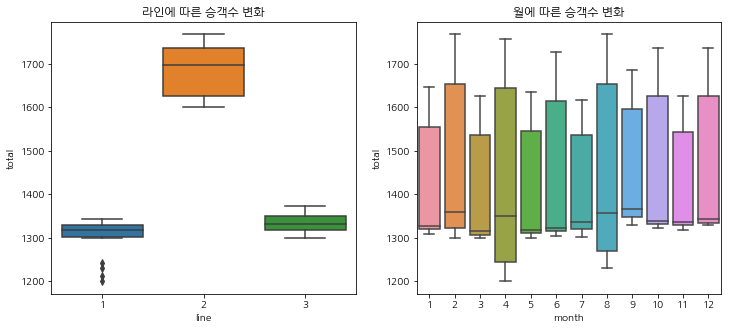

In [141]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

sns.boxplot(data=dat, x='line', y='total', ax=ax[0])
ax[0].set_title('라인에 따른 승객수 변화')

sns.boxplot(data=dat, x='month', y='total', ax=ax[1])
ax[1].set_title('월에 따른 승객수 변화')
plt.show()

// 끝